# exp-gs-002-03 — H-AS + DOMAIN-04A gene-pair core

## 목적

홍주님 H-AS backbone(G+B+V+T+R+A+S)에 DOMAIN-04A의 **Logistic 전용 gene-pair 3개만** 추가한다. exact mutation은 넣지 않아 pair 블록의 독립 효과를 검증한다.

- Backbone: H-AS
- 추가 피처: `IDH1 × TP53`, `IDH1 × ATRX`, `APC × TP53`
- 고정: Logistic lbfgs, C=0.07, max_iter=2000, class_weight=balanced, StratifiedKFold-5
- seeds: 42 / 2024 / 777
- 평가: OOF Macro F1
- 누수: pair는 동일 샘플 내 두 유전자의 mutation 동시 발생 여부로 직접 만들며, test를 fit·통계·피처선택에 사용하지 않는다.
- NaN: test의 NaN 237개는 mutation/event로 처리하지 않는다.

> -02 exact 실험과 결합하지 않는다. 먼저 pair 블록만의 효용을 판단한다.

## 가설과 비교 기준

gene-pair는 단일 유전자 mutation으로 포착하지 못하는 동시 변이 패턴을 나타낸다. 기존 DOMAIN-04A 단일 제거 분석에서 Logistic의 `IDH1 × TP53`, `IDH1 × ATRX`는 제거 시 점수가 하락해 유효 신호 후보로 남았다.

비교 기준은 팀 H-AS 3-seed OOF Macro F1 **0.433329 ± 0.002785**이다. -02 exact의 결과는 별도 블록 결과이므로, pair 실험의 직접 기준으로 섞지 않는다.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:.6f}')


def find_eda_dir() -> Path:
    start = Path.cwd()
    for candidate in (start, *start.parents):
        direct = candidate / 'common' / 'exp-gs-002-memory-safe.py'
        from_project_root = candidate / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002' / 'common' / 'exp-gs-002-memory-safe.py'
        if direct.exists():
            return candidate
        if from_project_root.exists():
            return from_project_root.parent.parent
    raise FileNotFoundError('프로젝트 루트 또는 eda_pre_002에서 실행하세요.')


EDA_DIR = find_eda_dir()
ROOT = EDA_DIR.parents[3]
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'

RUN_ID = 'exp-gs-002-03'
CANDIDATE = 'H-AS-LR-pair'
MODEL = 'logistic'
SEEDS = (42, 2024, 777)
REFERENCE_H_AS_MEAN = 0.433329
REFERENCE_H_AS_STD = 0.002785

assert RUNNER.exists(), RUNNER
assert RESULT_DIR.exists(), RESULT_DIR

{
    'runner': RUNNER,
    'result_dir': RESULT_DIR,
    'candidate': CANDIDATE,
    'pair_features': ('IDH1×TP53', 'IDH1×ATRX', 'APC×TP53'),
    'seeds': SEEDS,
    'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
    'reference_h_as_oof_macro_f1': f'{REFERENCE_H_AS_MEAN:.6f} ± {REFERENCE_H_AS_STD:.6f}',
}

/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result'),
 'candidate': 'H-AS-LR-pair',
 'pair_features': ('IDH1×TP53', 'IDH1×ATRX', 'APC×TP53'),
 'seeds': (42, 2024, 777),
 'fixed_model': 'lbfgs / C=0.07 / max_iter=2000 / class_weight=balanced',
 'reference_h_as_oof_macro_f1': '0.433329 ± 0.002785'}

## 실행

기본값은 `False`다. True로 변경 후 실행하면 seed별 tqdm과 실행기 내부 fold tqdm이 표시된다. 완료된 seed 결과는 result/에 보존된다.

In [2]:
RUN_EXPERIMENT = True # 실제 실행 시에만 True로 변경

if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc=f'{RUN_ID} | {CANDIDATE} | 3-seed', unit='seed'):
        command = [
            sys.executable,
            str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', CANDIDATE,
            '--model', MODEL,
            '--seed', str(seed),
        ]
        completed = subprocess.run(command, cwd=ROOT, check=False)
        if completed.returncode != 0:
            raise RuntimeError(f'seed={seed} 실행 실패 (returncode={completed.returncode})')
else:
    print('미실행 상태입니다. 실행하려면 RUN_EXPERIMENT = True로 변경하세요.')

row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.25it/s]
H-AS-LR-pair | logistic | seed 42: 100%|██████████| 5/5 [04:50<00:00, 58.04s/it]


{
  "experiment_id": "H-AS-LR-pair",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.42970069003860395,
  "oof_accuracy": 0.4192872117400419,
  "fold_macro_f1_mean": 0.42876373230298903,
  "fold_macro_f1_std": 0.011267846568929697,
  "feature_count_mean": 8216.2,
  "runtime_seconds": 290.25886824999907,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.30it/s]88s/seed]
H-AS-LR-pair | logistic | seed 2024: 100%|██████████| 5/5 [04:49<00:00, 57.81s/it]


{
  "experiment_id": "H-AS-LR-pair",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4330264967061508,
  "oof_accuracy": 0.42122238348653446,
  "fold_macro_f1_mean": 0.43296636897947194,
  "fold_macro_f1_std": 0.007942901346479856,
  "feature_count_mean": 8216.0,
  "runtime_seconds": 289.15975404100027,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.08it/s]14s/seed]
H-AS-LR-pair | logistic | seed 777: 100%|██████████| 5/5 [04:50<00:00, 58.16s/it]


{
  "experiment_id": "H-AS-LR-pair",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.4312702971214176,
  "oof_accuracy": 0.42154491211094985,
  "fold_macro_f1_mean": 0.4304901006741839,
  "fold_macro_f1_std": 0.010202875696797118,
  "feature_count_mean": 8211.4,
  "runtime_seconds": 290.8462669170003,
  "convergence_warning_count": 5,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


exp-gs-002-03 | H-AS-LR-pair | 3-seed: 100%|██████████| 3/3 [15:46<00:00, 315.55s/seed]


## 3-seed 요약

세 seed가 모두 생성된 경우에만 평균·표준편차를 계산한다. convergence warning, leakage check, NaN→mutation count를 함께 저장한다.

In [3]:
def oof_path(seed: int) -> Path:
    return RESULT_DIR / f'{RUN_ID}_{CANDIDATE}_{MODEL}_seed{seed}_oof.csv'


def class_f1_path(seed: int) -> Path:
    return RESULT_DIR / f'{RUN_ID}_{CANDIDATE}_{MODEL}_seed{seed}_class_f1.csv'


missing = [oof_path(seed) for seed in SEEDS if not oof_path(seed).exists()]

if missing:
    print('아직 필요한 OOF 결과 파일이 없습니다:')
    for path in missing:
        print(' -', path.name)
else:
    runs = pd.concat([pd.read_csv(oof_path(seed)) for seed in SEEDS], ignore_index=True)
    summary = (
        runs.groupby(['experiment_id', 'model'], as_index=False)
        .agg(
            seed_count=('seed', 'nunique'),
            oof_macro_f1_mean=('oof_macro_f1', 'mean'),
            oof_macro_f1_std=('oof_macro_f1', 'std'),
            oof_accuracy_mean=('oof_accuracy', 'mean'),
            feature_count_mean=('feature_count_mean', 'mean'),
            runtime_seconds_mean=('runtime_seconds', 'mean'),
            convergence_warning_count=('convergence_warning_count', 'sum'),
            leakage_check=('leakage_check', 'all'),
            nan_as_mutation_count=('nan_as_mutation_count', 'max'),
        )
    )
    summary['delta_vs_team_H_AS_reference'] = summary['oof_macro_f1_mean'] - REFERENCE_H_AS_MEAN
    summary_path = RESULT_DIR / f'{RUN_ID}_3seed_summary.csv'
    summary.to_csv(summary_path, index=False)
    display(runs.sort_values('seed'))
    display(summary)
    print(f'저장 완료: {summary_path.name}')

,experiment_id,model,seed,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-pair,logistic,42,0.429701,0.419287,0.428764,0.011268,8216.200000,290.258868,5,True,0
2,H-AS-LR-pair,logistic,777,0.431270,0.421545,0.430490,0.010203,8211.400000,290.846267,5,True,0
1,H-AS-LR-pair,logistic,2024,0.433026,0.421222,0.432966,0.007943,8216.000000,289.159754,5,True,0


,experiment_id,model,seed_count,oof_macro_f1_mean,oof_macro_f1_std,oof_accuracy_mean,feature_count_mean,runtime_seconds_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_team_H_AS_reference
0,H-AS-LR-pair,logistic,3,0.431332,0.001664,0.420685,8214.533333,290.088296,15,True,0,-0.001997


저장 완료: exp-gs-002-03_3seed_summary.csv


## 클래스별 F1 및 시각화

클래스별 F1은 어느 암종에서 pair가 신호를 주는지 확인하는 보조 지표다. 최종 판단은 OOF 평균·표준편차, 수렴 경고, leakage/NaN 점검을 함께 사용한다.

,class,class_f1_mean,class_f1_std,support
0,SKCM,0.864344,0.001483,276.000000
1,ACC,0.773887,0.014178,72.000000
2,COAD,0.723441,0.009559,223.000000
3,THCA,0.678739,0.006770,324.000000
4,UCEC,0.546181,0.010147,198.000000
5,TGCT,0.543425,0.015244,124.000000
6,LUSC,0.528160,0.017138,178.000000
7,STES,0.495932,0.005795,379.000000
8,BRCA,0.481508,0.003595,786.000000
9,LGG,0.465511,0.012384,229.000000


,class,class_f1_mean,class_f1_std,support
16,DLBC,0.356214,0.040298,38.000000
17,PRAD,0.339712,0.005097,266.000000
18,HNSC,0.335859,0.012085,223.000000
19,GBMLGG,0.330556,0.010963,461.000000
20,BLCA,0.324937,0.008598,104.000000
21,PCPG,0.281463,0.007891,147.000000
22,THYM,0.236484,0.016590,98.000000
23,KIPAN,0.193240,0.009902,515.000000
24,SARC,0.190990,0.010639,198.000000
25,KIRC,0.180308,0.012900,334.000000


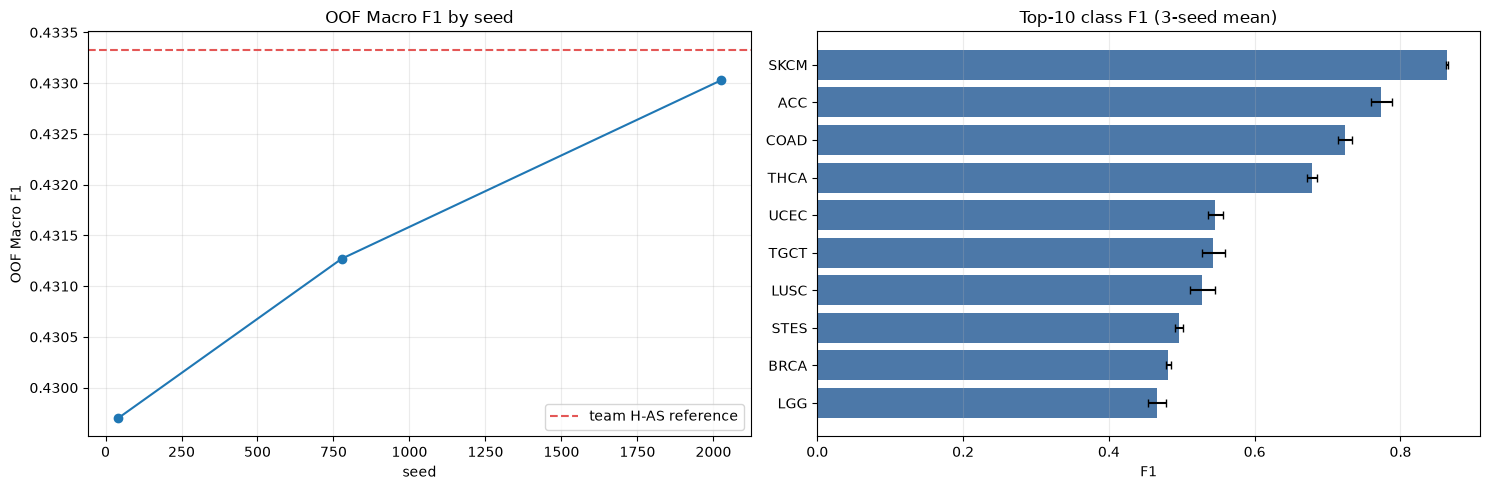

저장 완료: exp-gs-002-03_class_f1_3seed_summary.csv


In [4]:
missing_class = [class_f1_path(seed) for seed in SEEDS if not class_f1_path(seed).exists()]

if missing_class:
    print('아직 필요한 class F1 결과 파일이 없습니다:')
    for path in missing_class:
        print(' -', path.name)
else:
    class_runs = pd.concat([pd.read_csv(class_f1_path(seed)) for seed in SEEDS], ignore_index=True)
    class_summary = (
        class_runs.groupby('class', as_index=False)
        .agg(
            class_f1_mean=('f1-score', 'mean'),
            class_f1_std=('f1-score', 'std'),
            support=('support', 'mean'),
        )
        .sort_values('class_f1_mean', ascending=False)
        .reset_index(drop=True)
    )
    class_summary_path = RESULT_DIR / f'{RUN_ID}_class_f1_3seed_summary.csv'
    class_summary.to_csv(class_summary_path, index=False)

    display(class_summary.head(10))
    display(class_summary.tail(10))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ordered_runs = runs.sort_values('seed')
    axes[0].plot(ordered_runs['seed'], ordered_runs['oof_macro_f1'], marker='o')
    axes[0].axhline(REFERENCE_H_AS_MEAN, color='#E45756', linestyle='--', label='team H-AS reference')
    axes[0].set_title('OOF Macro F1 by seed')
    axes[0].set_xlabel('seed')
    axes[0].set_ylabel('OOF Macro F1')
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    top = class_summary.head(10).sort_values('class_f1_mean')
    axes[1].barh(top['class'], top['class_f1_mean'], xerr=top['class_f1_std'], capsize=3, color='#4C78A8')
    axes[1].set_title('Top-10 class F1 (3-seed mean)')
    axes[1].set_xlabel('F1')
    axes[1].grid(axis='x', alpha=0.25)

    plt.tight_layout()
    plt.show()
    print(f'저장 완료: {class_summary_path.name}')

## 판정 및 다음 단계

- 통과: H-AS 기준보다 일관된 Macro F1 개선, 허용 가능한 std·수렴 경고, leakage_check=True / nan_as_mutation_count=0
- 보류: 개선폭이 변동성보다 작거나 warning이 크게 늘어난 경우
- 다음: exact(-02)와 pair(-03)가 각각 통과할 때만 exact+pair 결합 실험을 진행한다. 둘 중 하나라도 보류면 전체 조합을 먼저 시도하지 않는다.